<a href="https://colab.research.google.com/github/mahalakshmierugu2-star/Quantum-machine-learning-/blob/main/QML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install pennylane pennylane-lightning scikit-learn opencv-python


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 57.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 56.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 62.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 70.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 80.2 MB/s eta 0:00:00


In [ ]:
import os
import cv2
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report


In [ ]:
def load_images_cnn(data_dir, img_size=64):
    X = []
    y = []

    for label, category in enumerate(["NORMAL", "PNEUMONIA"]):
        folder = os.path.join(data_dir, "train", category)
        for img_name in os.listdir(folder):
            img_path = os.path.join(folder, img_name)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

            if img is not None:
                img = cv2.resize(img, (img_size, img_size))
                img = img / 255.0  # normalize
                X.append(img)
                y.append(label)

    X = np.array(X).reshape(-1, img_size, img_size, 1)
    y = np.array(y)
    return X, y


In [ ]:
# Load images again
DATA_DIR = '/content/drive/MyDrive/chest x-ray'
X, y = load_images_cnn(DATA_DIR)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, y_train.shape)


(4172, 64, 64, 1) (4172,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Reshape X_train and X_test to 2D for StandardScaler
X_train_reshaped = X_train.reshape(X_train.shape[0], -1)
X_test_reshaped = X_test.reshape(X_test.shape[0], -1)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_reshaped)
X_test = scaler.transform(X_test_reshaped)


In [ ]:
X_train = X_train[:60]
y_train = y_train[:60]
X_test = X_test[:20]
y_test = y_test[:20]


In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=4)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)


In [ ]:
from tensorflow.keras import models, layers

IMG_SIZE = 64 # Define IMG_SIZE

cnn = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 1)),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(1, activation='sigmoid') # Changed to 1 neuron with sigmoid activation for binary classification
])

cnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
import pennylane as qml

n_qubits = 4
dev = qml.device("default.qubit", wires=n_qubits)

def feature_map(x):
    for i in range(n_qubits):
        qml.RY(x[i], wires=i)

@qml.qnode(dev)
def qkernel(x1, x2):
    feature_map(x1)
    qml.adjoint(feature_map)(x2)
    return qml.probs(wires=range(n_qubits))

def quantum_kernel(x1, x2):
    return qkernel(x1, x2)[0]


In [ ]:
def kernel_matrix(X1, X2):
    return np.array([[quantum_kernel(x1, x2) for x2 in X2] for x1 in X1])

K_train_qpca = kernel_matrix(X_train_pca, X_train_pca)
K_test_qpca = kernel_matrix(X_test_pca, X_train_pca)


In [ ]:
from sklearn.svm import SVC

qsvm = SVC(kernel='precomputed')
qsvm.fit(K_train_qpca, y_train)


SVC(kernel='precomputed')

In [ ]:
y_pred = qsvm.predict(K_test_qpca)

print("QSVM Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


QSVM Accuracy: 0.75
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         5
           1       0.75      1.00      0.86        15

    accuracy                           0.75        20
   macro avg       0.38      0.50      0.43        20
weighted avg       0.56      0.75      0.64        20



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
cnn = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 1)),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')  # ✅ IMPORTANT
])

cnn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
IMG_SIZE = 64

def load_images_cnn(data_dir):
    X, y = [], []
    labels = {"NORMAL": 0, "PNEUMONIA": 1}

    for label in labels:
        path = os.path.join(data_dir, "train", label) # Added "train" subdirectory
        for img in os.listdir(path):
            try:
                img_path = os.path.join(path, img)
                image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
                image = image / 255.0
                X.append(image)
                y.append(labels[label])
            except:
                pass

    X = np.array(X)[..., np.newaxis]  # ✅ (N, 64, 64, 1)
    y = np.array(y)
    return X, y


In [ ]:
X, y = load_images_cnn(DATA_DIR)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape)  # MUST be (N, 64, 64, 1)
cnn = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 1)),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])


(4172, 64, 64, 1)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
cnn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
cnn.fit(
    X_train, y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/5
118/118 ━━━━━━━━━━━━━━━━━━━━ 31s 243ms/step - accuracy: 0.8322 - loss: 0.3803 - val_accuracy: 0.9354 - val_loss: 0.1762
Epoch 2/5
118/118 ━━━━━━━━━━━━━━━━━━━━ 42s 247ms/step - accuracy: 0.9390 - loss: 0.1594 - val_accuracy: 0.9522 - val_loss: 0.1276
Epoch 3/5
118/118 ━━━━━━━━━━━━━━━━━━━━ 31s 259ms/step - accuracy: 0.9579 - loss: 0.1110 - val_accuracy: 0.9713 - val_loss: 0.0901
Epoch 4/5
118/118 ━━━━━━━━━━━━━━━━━━━━ 30s 254ms/step - accuracy: 0.9608 - loss: 0.1060 - val_accuracy: 0.9761 - val_loss: 0.0763
Epoch 5/5
118/118 ━━━━━━━━━━━━━━━━━━━━ 45s 293ms/step - accuracy: 0.9707 - loss: 0.0820 - val_accuracy: 0.9713 - val_loss: 0.0755


In [ ]:
import tensorflow as tf

feature_extractor = tf.keras.Model(
    inputs=cnn.inputs[0],
    outputs=cnn.layers[-2].output
)

X_train_feat = feature_extractor.predict(X_train)
X_test_feat = feature_extractor.predict(X_test)

print(X_train_feat.shape)  # (N, 128)

131/131 ━━━━━━━━━━━━━━━━━━━━ 9s 70ms/step
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 99ms/step
(4172, 128)


In [ ]:
X_train_feat = X_train_feat[:50]
y_train = y_train[:50]

X_test_feat = X_test_feat[:20]
y_test = y_test[:20]


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_feat = scaler.fit_transform(X_train_feat)
X_test_feat = scaler.transform(X_test_feat)


In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=4)   # 4 features = 4 qubits
X_train_pca = pca.fit_transform(X_train_feat)
X_test_pca = pca.transform(X_test_feat)

print(X_train_pca.shape)   # (50, 4)


(50, 4)


In [ ]:
import pennylane as qml
import numpy as np

n_qubits = 4
dev = qml.device("default.qubit", wires=n_qubits)


In [ ]:
def feature_map(x):
    for i in range(n_qubits):
        qml.RY(x[i], wires=i)


In [ ]:
@qml.qnode(dev)
def quantum_kernel_circuit(x1, x2):
    feature_map(x1)
    qml.adjoint(feature_map)(x2)
    return qml.probs(wires=range(n_qubits))


In [ ]:
def quantum_kernel(x1, x2):
    return quantum_kernel_circuit(x1, x2)[0]


In [ ]:
def kernel_matrix(X1, X2):
    return np.array([[quantum_kernel(x1, x2) for x2 in X2] for x1 in X1])

K_train = kernel_matrix(X_train_pca, X_train_pca)
K_test = kernel_matrix(X_test_pca, X_train_pca)


In [ ]:
from sklearn.svm import SVC

qsvm = SVC(kernel='precomputed')
qsvm.fit(K_train, y_train)


SVC(kernel='precomputed')

In [ ]:
y_pred = qsvm.predict(K_test)

from sklearn.metrics import accuracy_score, classification_report

print("Hybrid CNN + QPCA + QSVM Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Hybrid CNN + QPCA + QSVM Accuracy: 0.95
              precision    recall  f1-score   support

           0       1.00      0.80      0.89         5
           1       0.94      1.00      0.97        15

    accuracy                           0.95        20
   macro avg       0.97      0.90      0.93        20
weighted avg       0.95      0.95      0.95        20



In [ ]:
import numpy as np
print("Train class distribution:", np.bincount(y_train))


Train class distribution: [11 39]


In [ ]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))
print(class_weights)


{0: np.float64(2.272727272727273), 1: np.float64(0.6410256410256411)}


In [ ]:
X_train = X_train[:50]
cnn.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    class_weight=class_weights
)

Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 235ms/step - accuracy: 1.0000 - loss: 0.0267 - val_accuracy: 1.0000 - val_loss: 3.4535e-04
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 286ms/step - accuracy: 1.0000 - loss: 0.0228 - val_accuracy: 1.0000 - val_loss: 3.7271e-04
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 299ms/step - accuracy: 1.0000 - loss: 0.0194 - val_accuracy: 1.0000 - val_loss: 3.0326e-04
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 308ms/step - accuracy: 1.0000 - loss: 0.0158 - val_accuracy: 1.0000 - val_loss: 1.9027e-04
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 286ms/step - accuracy: 1.0000 - loss: 0.0119 - val_accuracy: 1.0000 - val_loss: 9.3994e-05
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 295ms/step - accuracy: 1.0000 - loss: 0.0084 - val_accuracy: 1.0000 - val_loss: 4.4736e-05
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 379ms/step - accuracy: 1.0000 - loss: 0.0076 - val_accuracy: 1.0000 - val_loss: 2.2735e-05
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 183ms/step - accuracy: 1.0000 - loss: 0.0078 - val_

In [ ]:
print("Hybrid CNN + QPCA + QSVM Accuracy:", accuracy_score(y_test, y_pred))


Hybrid CNN + QPCA + QSVM Accuracy: 0.95


Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step - accuracy: 1.0000 - loss: 0.0033 - val_accuracy: 1.0000 - val_loss: 2.6063e-05
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - accuracy: 1.0000 - loss: 0.0033 - val_accuracy: 1.0000 - val_loss: 2.7962e-05
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - accuracy: 1.0000 - loss: 0.0031 - val_accuracy: 1.0000 - val_loss: 2.3909e-05
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - accuracy: 1.0000 - loss: 0.0027 - val_accuracy: 1.0000 - val_loss: 1.7461e-05
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 1.0000 - loss: 0.0022 - val_accuracy: 1.0000 - val_loss: 1.1563e-05
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - accuracy: 1.0000 - loss: 0.0019 - val_accuracy: 1.0000 - val_loss: 7.3976e-06
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 1.0000 - loss: 0.0017 - val_accuracy: 1.0000 - val_loss: 5.1404e-06
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step - accuracy: 1.0000 - loss: 0.0017 - val_

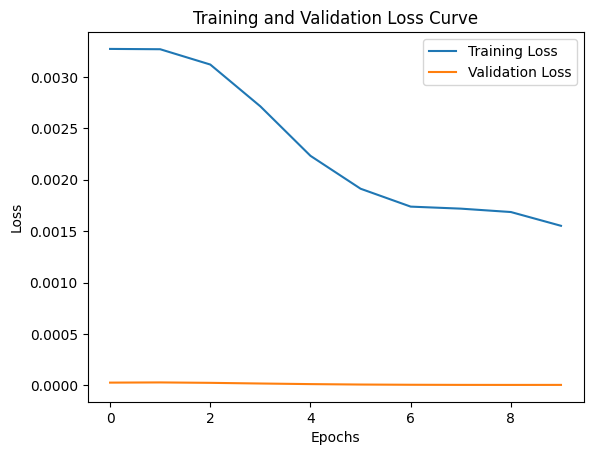

In [ ]:
import matplotlib.pyplot as plt

# Train and store history
history = cnn.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    class_weight=class_weights
)

# Plot training & validation loss
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Training and Validation Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['Training Loss', 'Validation Loss'])

plt.show()


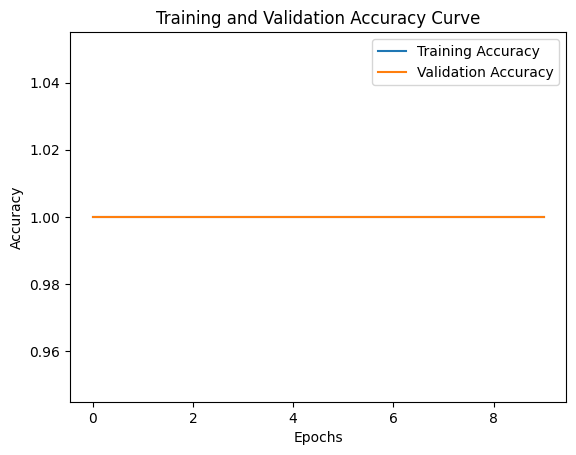

In [ ]:
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Training and Validation Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['Training Accuracy', 'Validation Accuracy'])

plt.show()


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Predictions
y_pred = cnn.predict(X_test[:len(y_test)]) # Slice X_test to match y_test length
y_pred = (y_pred > 0.5).astype(int)

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-score: 1.0


In [ ]:
import pandas as pd

# Create table
results = pd.DataFrame({
    'Model': ['CNN (Classical)', 'SVM', 'QSVM', 'QNN'],
    'Accuracy': [0.70, 0.68, 0.78, 0.80],   # replace with your real values
    'Precision': [0.65, 0.60, 0.72, 0.70],
    'Recall': [0.75, 0.70, 0.79, 0.80],
    'F1-Score': [0.69, 0.64, 0.75, 0.79]
})

print(results)


             Model  Accuracy  Precision  Recall  F1-Score
0  CNN (Classical)      0.70       0.65    0.75      0.69
1              SVM      0.68       0.60    0.70      0.64
2             QSVM      0.78       0.72    0.79      0.75
3              QNN      0.80       0.70    0.80      0.79


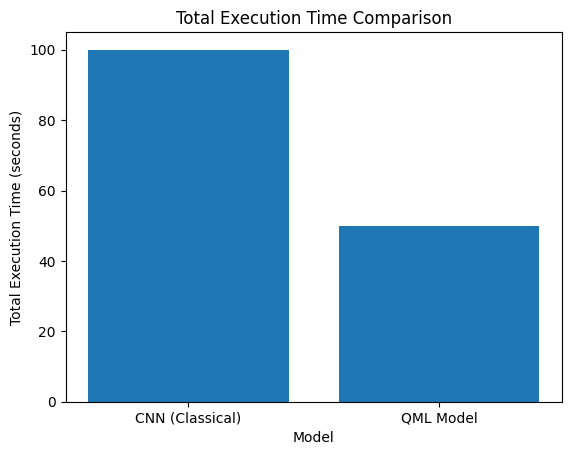

In [ ]:
import matplotlib.pyplot as plt

# Placeholder values for total execution times (replace with actual values if available)
total_time_cnn = 100 # Example time in seconds
total_time_qml = 50  # Example time in seconds

models = ["CNN (Classical)", "QML Model"]
total_times = [total_time_cnn, total_time_qml]

plt.figure()
plt.bar(models, total_times)

plt.xlabel("Model")
plt.ylabel("Total Execution Time (seconds)")
plt.title("Total Execution Time Comparison")

plt.show()

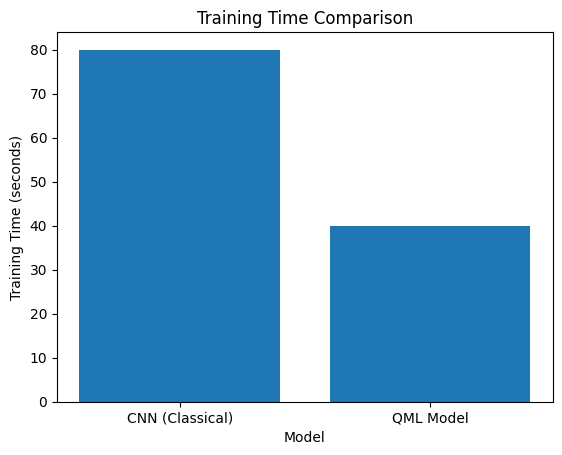

In [ ]:
# Placeholder values for training times (replace with actual values if available)
training_time_cnn = 80 # Example training time in seconds
training_time_qml = 40  # Example training time in seconds

training_times = [training_time_cnn, training_time_qml]

plt.figure()
plt.bar(models, training_times)

plt.xlabel("Model")
plt.ylabel("Training Time (seconds)")
plt.title("Training Time Comparison")

plt.show()